In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os
from pathlib import Path

ROOT = Path.cwd().parent   # vì notebook nằm trong folder notebook/
DATA_DIR = ROOT / "dataset"
# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "datathon_image_phase_C"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def format_billions(x, pos):
    return f"{x/1e9:.1f}B"

def format_millions(x, pos):
    return f"{x/1e6:.1f}M"

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

### Đọc và chuẩn bị dữ liệu

In [2]:
orders = pd.read_csv(DATA_DIR/"orders.csv")
order_items = pd.read_csv(DATA_DIR/"order_items.csv")
products = pd.read_csv(DATA_DIR/"products.csv")
inventory = pd.read_csv(DATA_DIR/"inventory.csv")
returns = pd.read_csv(DATA_DIR/"returns.csv")
shipments = pd.read_csv(DATA_DIR/"shipments.csv")
reviews = pd.read_csv(DATA_DIR/"reviews.csv")
geography = pd.read_csv(DATA_DIR/"geography.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])
shipments["ship_date"] = pd.to_datetime(shipments["ship_date"])
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])
reviews["review_date"] = pd.to_datetime(reviews["review_date"])

order_items["line_revenue"] = order_items["quantity"] * order_items["unit_price"]

order_detail = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(
        orders[[
            "order_id", "order_date", "customer_id", "zip",
            "order_status", "payment_method", "device_type", "order_source"
        ]],
        on="order_id",
        how="left"
    )
)

order_detail["year_month"] = order_detail["order_date"].dt.to_period("M").dt.to_timestamp()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29524\2536977200.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(DATA_DIR/"order_items.csv")


### Ở Phần trước,traffic tăng nhưng conversion giảm. Một nguyên nhân có thể là:

Khách vào website nhưng sản phẩm hết hàng, thiếu size, hoặc fill rate thấp.

Với inventory.csv, bạn có thể kiểm tra:

category nào stockout nhiều nhất,
category nào fill rate thấp,
stockout có đi cùng doanh số thấp hơn không,
có overstock ở category yếu không.

Saving figure c1_stockout_days_by_category


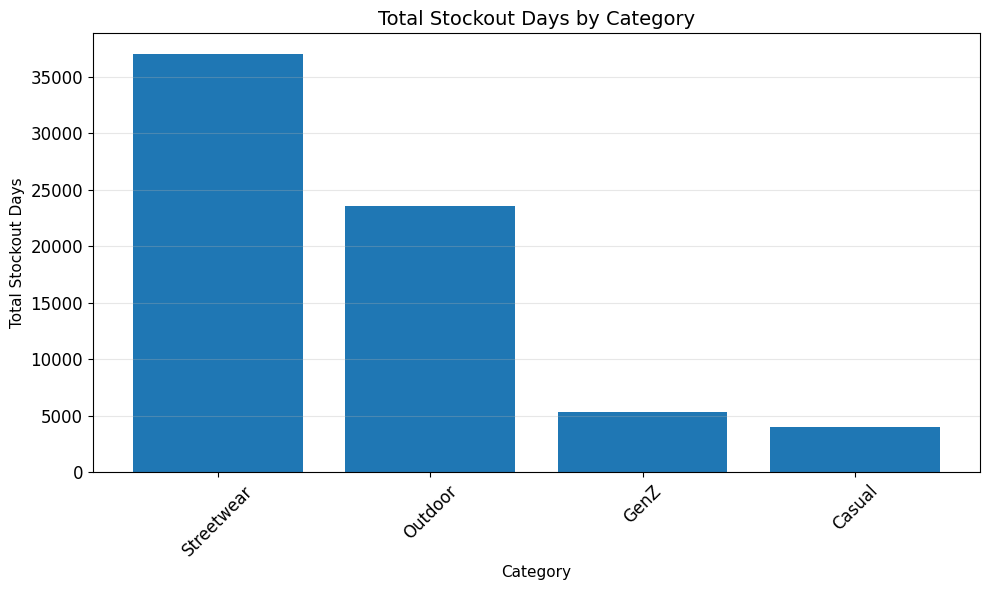

,category,total_stockout_days,avg_fill_rate,avg_days_of_supply,avg_sell_through
3,Streetwear,36993,0.960248,887.136692,0.159754
2,Outdoor,23552,0.962705,1068.837815,0.135084
1,GenZ,5368,0.961718,718.812174,0.167978
0,Casual,4012,0.961823,459.132629,0.168390


In [3]:
stockout_cat = (
    inventory
    .groupby("category", as_index=False)
    .agg(
        total_stockout_days=("stockout_days", "sum"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_days_of_supply=("days_of_supply", "mean"),
        avg_sell_through=("sell_through_rate", "mean")
    )
    .sort_values("total_stockout_days", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(stockout_cat["category"], stockout_cat["total_stockout_days"])

plt.title("Total Stockout Days by Category")
plt.xlabel("Category")
plt.ylabel("Total Stockout Days")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c1_stockout_days_by_category")
plt.show()

display(stockout_cat)

Saving figure c1_fill_rate_by_category


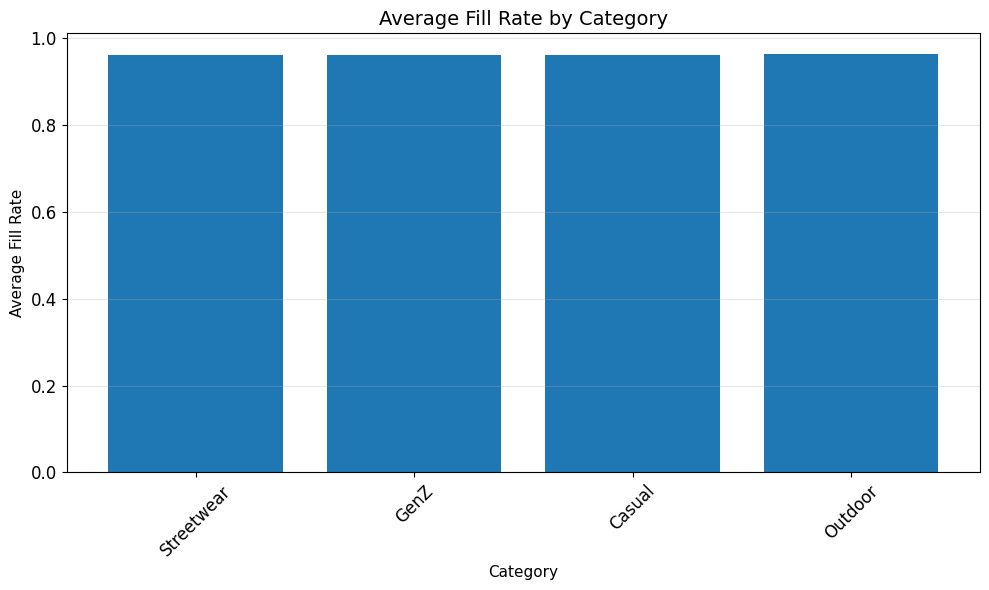

In [4]:
fill_rate_cat = (
    inventory
    .groupby("category", as_index=False)
    .agg(avg_fill_rate=("fill_rate", "mean"))
    .sort_values("avg_fill_rate", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.bar(fill_rate_cat["category"], fill_rate_cat["avg_fill_rate"])

plt.title("Average Fill Rate by Category")
plt.xlabel("Category")
plt.ylabel("Average Fill Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c1_fill_rate_by_category")
plt.show()

Saving figure c1_stockout_vs_units_sold


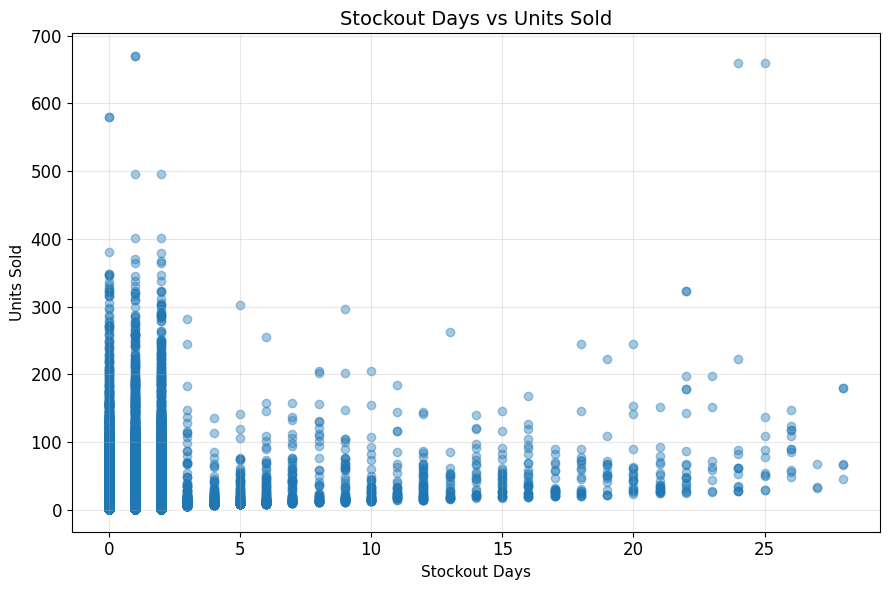

Correlation between stockout_days and units_sold: 0.1199060164696232


In [5]:
plt.figure(figsize=(9, 6))

plt.scatter(
    inventory["stockout_days"],
    inventory["units_sold"],
    alpha=0.4
)

plt.title("Stockout Days vs Units Sold")
plt.xlabel("Stockout Days")
plt.ylabel("Units Sold")
plt.grid(alpha=0.3)

plt.tight_layout()
save_fig("c1_stockout_vs_units_sold")
plt.show()

corr_stockout_sales = inventory["stockout_days"].corr(inventory["units_sold"])
print("Correlation between stockout_days and units_sold:", corr_stockout_sales)

### Category nào bán được nhưng bị trả hàng nhiều?

In [6]:
returned_items = (
    returns
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        return_quantity=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum")
    )
)

item_level = order_detail.merge(
    returned_items,
    on=["order_id", "product_id"],
    how="left"
)

item_level["return_quantity"] = item_level["return_quantity"].fillna(0)
item_level["refund_amount"] = item_level["refund_amount"].fillna(0)
item_level["has_return"] = (item_level["return_quantity"] > 0).astype(int)

Saving figure c2_return_rate_by_category


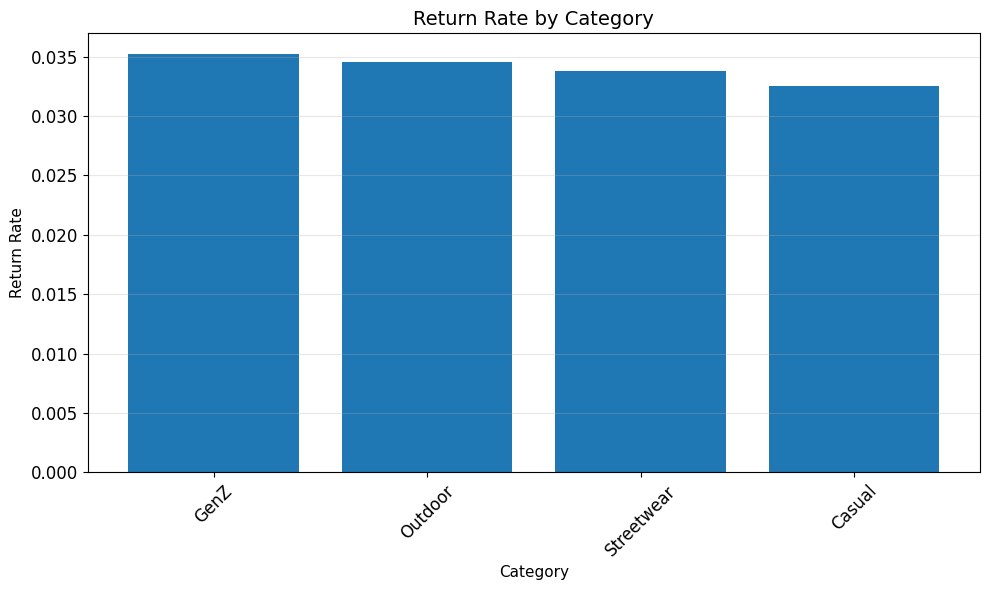

,category,total_items,returned_items,revenue,refund_amount,return_rate,refund_rate
1,GenZ,166848,5873.0,3.435991e+08,1.114977e+07,0.035200,0.032450
2,Outdoor,1170000,40417.0,2.494883e+09,7.871751e+07,0.034544,0.031552
3,Streetwear,1768826,59812.0,1.313135e+10,4.067659e+08,0.033815,0.030977
0,Casual,107469,3499.0,4.606484e+08,1.402709e+07,0.032558,0.030451


In [7]:
return_cat = (
    item_level
    .groupby("category", as_index=False)
    .agg(
        total_items=("quantity", "sum"),
        returned_items=("return_quantity", "sum"),
        revenue=("line_revenue", "sum"),
        refund_amount=("refund_amount", "sum")
    )
)

return_cat["return_rate"] = return_cat["returned_items"] / return_cat["total_items"]
return_cat["refund_rate"] = return_cat["refund_amount"] / return_cat["revenue"]

return_cat = return_cat.sort_values("return_rate", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(return_cat["category"], return_cat["return_rate"])

plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c2_return_rate_by_category")
plt.show()

display(return_cat)

Saving figure c2_return_rate_by_size


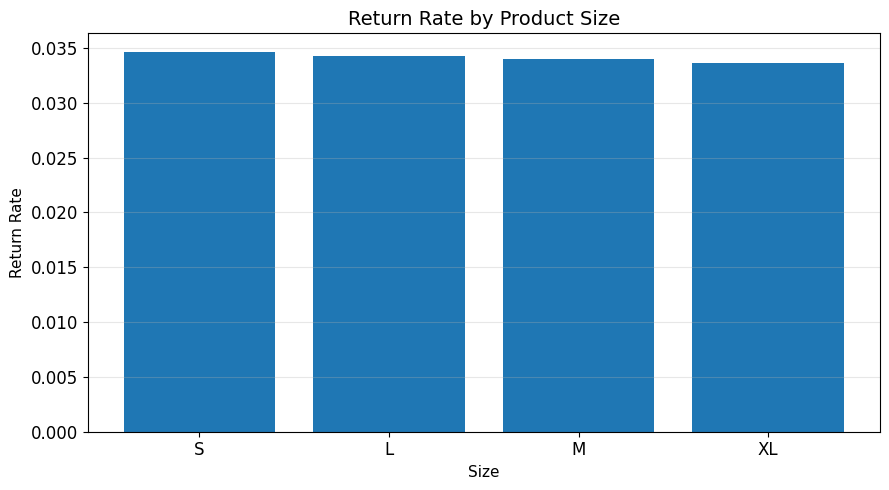

,size,total_items,returned_items,return_rate
2,S,774468,26797.0,0.034601
0,L,778599,26688.0,0.034277
1,M,792889,26947.0,0.033986
3,XL,867187,29169.0,0.033636


In [8]:
return_size = (
    item_level
    .groupby("size", as_index=False)
    .agg(
        total_items=("quantity", "sum"),
        returned_items=("return_quantity", "sum")
    )
)

return_size["return_rate"] = return_size["returned_items"] / return_size["total_items"]
return_size = return_size.sort_values("return_rate", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(return_size["size"], return_size["return_rate"])

plt.title("Return Rate by Product Size")
plt.xlabel("Size")
plt.ylabel("Return Rate")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c2_return_rate_by_size")
plt.show()

display(return_size)

Saving figure c2_top_return_reasons


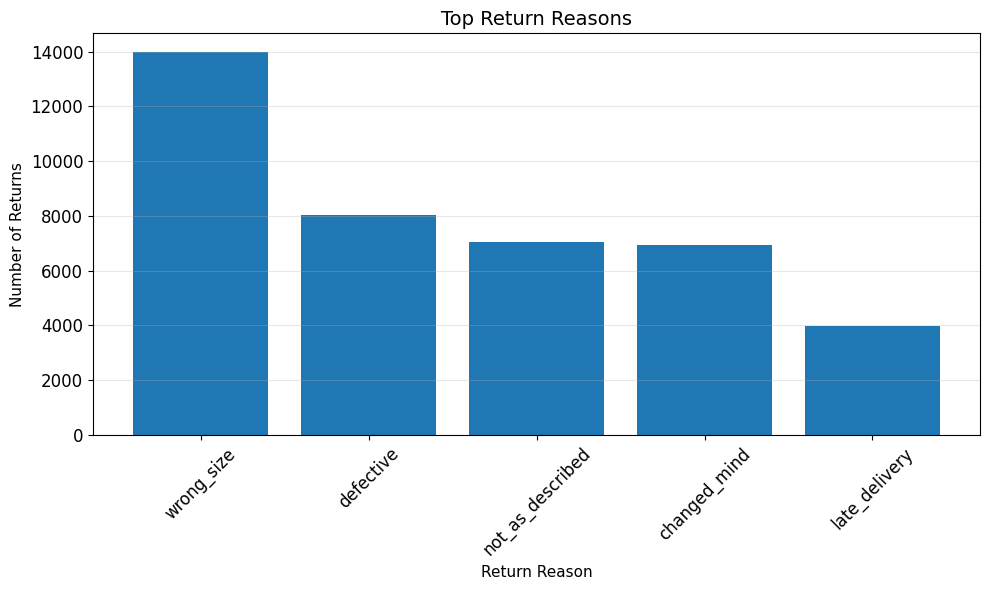

,return_reason,return_count,refund_amount
4,wrong_size,13967,1.766872e+08
1,defective,8020,1.035991e+08
3,not_as_described,7035,9.065319e+07
0,changed_mind,6931,8.972176e+07
2,late_delivery,3986,4.993721e+07


In [9]:
return_reason = (
    returns
    .groupby("return_reason", as_index=False)
    .agg(
        return_count=("return_id", "count"),
        refund_amount=("refund_amount", "sum")
    )
    .sort_values("return_count", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(return_reason["return_reason"], return_reason["return_count"])

plt.title("Top Return Reasons")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c2_top_return_reasons")
plt.show()

display(return_reason)

Shipping chậm có thể làm:

+ review thấp,
+ return cao,
+ customer không mua lại,
+ conversion giảm nếu khách thấy delivery estimate kém.

In [10]:
ship_detail = shipments.copy()
ship_detail["delivery_days"] = (
    ship_detail["delivery_date"] - ship_detail["ship_date"]
).dt.days

ship_detail = ship_detail.merge(
    orders[["order_id", "order_date", "zip", "order_source", "device_type", "payment_method"]],
    on="order_id",
    how="left"
)

ship_detail = ship_detail.merge(
    geography[["zip", "region", "city"]],
    on="zip",
    how="left"
)

# Add return flag
returned_orders = returns[["order_id"]].drop_duplicates()
returned_orders["has_return"] = 1

ship_detail = ship_detail.merge(returned_orders, on="order_id", how="left")
ship_detail["has_return"] = ship_detail["has_return"].fillna(0)

Saving figure c3_delivery_days_by_region


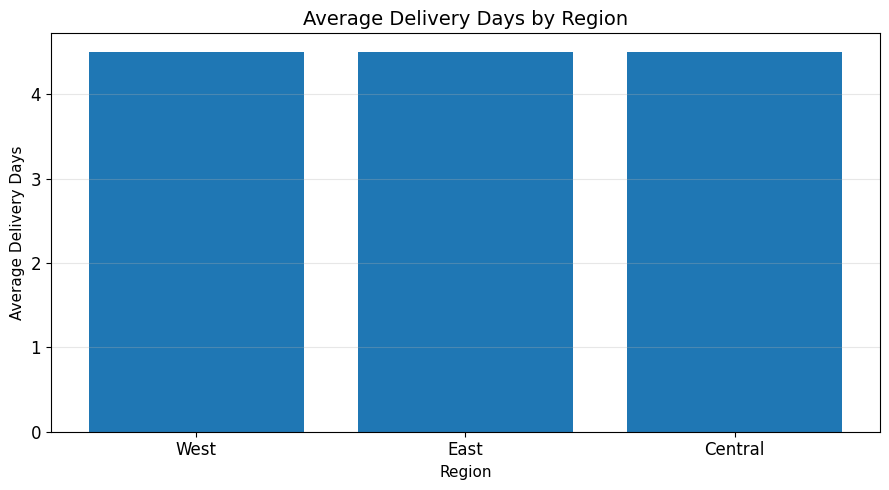

,region,avg_delivery_days,median_delivery_days,return_rate
2,West,4.499677,5.0,0.064626
1,East,4.499302,4.0,0.063265
0,Central,4.498637,4.0,0.063573


In [11]:
delivery_region = (
    ship_detail
    .groupby("region", as_index=False)
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        return_rate=("has_return", "mean")
    )
    .sort_values("avg_delivery_days", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(delivery_region["region"], delivery_region["avg_delivery_days"])

plt.title("Average Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c3_delivery_days_by_region")
plt.show()

display(delivery_region)

Saving figure c3_return_rate_by_delivery_bucket


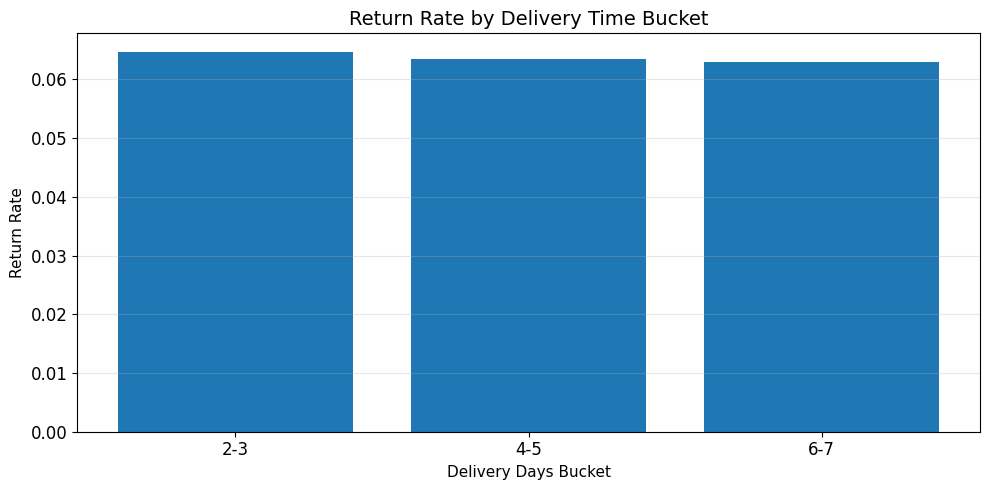

,delivery_bucket,orders,return_rate
0,2-3,188640,0.064626
1,4-5,188908,0.063454
2,6-7,188519,0.063039


In [12]:
ship_detail["delivery_bucket"] = pd.cut(
    ship_detail["delivery_days"],
    bins=[-1, 1, 3, 5, 7, 14, 100],
    labels=["0-1", "2-3", "4-5", "6-7", "8-14", "15+"]
)

delivery_return = (
    ship_detail
    .groupby("delivery_bucket", as_index=False, observed=True)
    .agg(
        orders=("order_id", "nunique"),
        return_rate=("has_return", "mean")
    )
)

plt.figure(figsize=(10, 5))
plt.bar(delivery_return["delivery_bucket"].astype(str), delivery_return["return_rate"])

plt.title("Return Rate by Delivery Time Bucket")
plt.xlabel("Delivery Days Bucket")
plt.ylabel("Return Rate")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c3_return_rate_by_delivery_bucket")
plt.show()

display(delivery_return)

### Trải nghiệm khách hàng có vấn đề ở đâu?

In [13]:
review_detail = (
    reviews
    .merge(products, on="product_id", how="left")
    .merge(
        orders[["order_id", "order_date", "order_source", "device_type", "payment_method"]],
        on="order_id",
        how="left"
    )
)

review_detail = review_detail.merge(returned_orders, on="order_id", how="left")
review_detail["has_return"] = review_detail["has_return"].fillna(0)

Saving figure c4_avg_rating_by_category


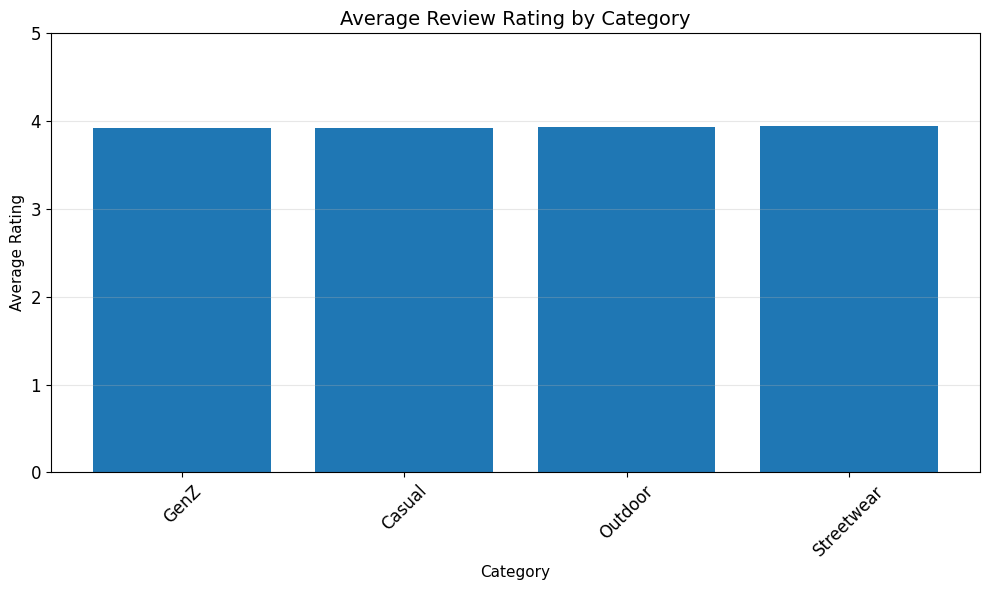

,category,avg_rating,review_count,return_rate
1,GenZ,3.922825,5792,0.0
0,Casual,3.923219,3790,0.0
2,Outdoor,3.933891,41265,0.0
3,Streetwear,3.939398,62704,0.0


In [14]:
rating_cat = (
    review_detail
    .groupby("category", as_index=False)
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("review_id", "count"),
        return_rate=("has_return", "mean")
    )
    .sort_values("avg_rating", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.bar(rating_cat["category"], rating_cat["avg_rating"])

plt.title("Average Review Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c4_avg_rating_by_category")
plt.show()

display(rating_cat)

Saving figure c4_return_rate_by_rating


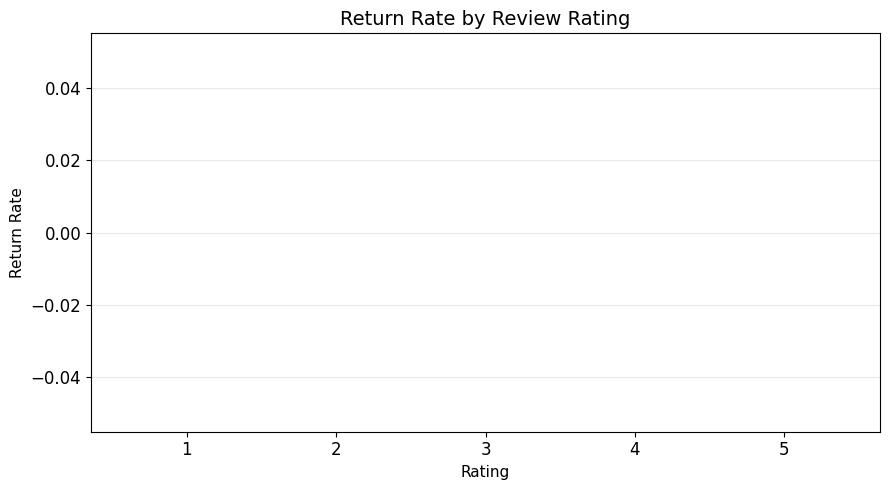

,rating,review_count,return_rate
0,1,5772,0.0
1,2,9095,0.0
2,3,17016,0.0
3,4,36412,0.0
4,5,45256,0.0


In [15]:
rating_return = (
    review_detail
    .groupby("rating", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        return_rate=("has_return", "mean")
    )
)

plt.figure(figsize=(9, 5))
plt.bar(rating_return["rating"], rating_return["return_rate"])

plt.title("Return Rate by Review Rating")
plt.xlabel("Rating")
plt.ylabel("Return Rate")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c4_return_rate_by_rating")
plt.show()

display(rating_return)

In [16]:
returns_by_item = (
    returns
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        return_records=("return_id", "nunique"),
        returned_units=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum")
    )
)

In [17]:
review_return = (
    reviews
    .merge(
        products[["product_id", "category", "segment", "size"]],
        on="product_id",
        how="left"
    )
    .merge(
        returns_by_item,
        on=["order_id", "product_id"],
        how="left"
    )
)

review_return["return_records"] = review_return["return_records"].fillna(0)
review_return["returned_units"] = review_return["returned_units"].fillna(0)
review_return["refund_amount"] = review_return["refund_amount"].fillna(0)

review_return["has_return"] = (review_return["returned_units"] > 0).astype(int)

In [18]:
rating_category_return = (
    review_return
    .groupby(["category", "rating"], as_index=False)
    .agg(
        review_count=("review_id", "nunique"),
        returned_review_count=("has_return", "sum"),
        return_records=("return_records", "sum"),
        returned_units=("returned_units", "sum"),
        refund_amount=("refund_amount", "sum")
    )
)

rating_category_return["return_rate"] = (
    rating_category_return["returned_review_count"] /
    rating_category_return["review_count"]
)

rating_category_return = rating_category_return.sort_values(
    ["category", "rating"]
)

display(rating_category_return)

,category,rating,review_count,returned_review_count,return_records,returned_units,refund_amount,return_rate
0,Casual,1,204,0,0.0,0.0,0.0,0.0
1,Casual,2,316,0,0.0,0.0,0.0,0.0
2,Casual,3,548,0,0.0,0.0,0.0,0.0
3,Casual,4,1221,0,0.0,0.0,0.0,0.0
4,Casual,5,1501,0,0.0,0.0,0.0,0.0
5,GenZ,1,291,0,0.0,0.0,0.0,0.0
6,GenZ,2,474,0,0.0,0.0,0.0,0.0
7,GenZ,3,900,0,0.0,0.0,0.0,0.0
8,GenZ,4,1853,0,0.0,0.0,0.0,0.0
9,GenZ,5,2274,0,0.0,0.0,0.0,0.0


In [19]:
review_orders = reviews[["order_id"]].drop_duplicates()
return_orders = returns[["order_id"]].drop_duplicates()

overlap_orders = review_orders.merge(return_orders, on="order_id", how="inner")

print("Number of reviewed orders:", review_orders["order_id"].nunique())
print("Number of returned orders:", return_orders["order_id"].nunique())
print("Number of orders with both review and return:", overlap_orders["order_id"].nunique())

Number of reviewed orders: 111369
Number of returned orders: 36062
Number of orders with both review and return: 0


In [20]:
rating_dist = (
    reviews
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby(["category", "rating"], as_index=False)
    .agg(review_count=("review_id", "nunique"))
)

pivot_rating = rating_dist.pivot(
    index="category",
    columns="rating",
    values="review_count"
).fillna(0)

pivot_rating_pct = pivot_rating.div(pivot_rating.sum(axis=1), axis=0)

display(pivot_rating_pct)

rating,1,2,3,4,5
category,,,,,
Casual,0.053826,0.083377,0.144591,0.322164,0.396042
GenZ,0.050242,0.081837,0.155387,0.319924,0.392610
Outdoor,0.051399,0.079729,0.152260,0.316806,0.399806
Streetwear,0.050332,0.079979,0.148077,0.323185,0.398428


Saving figure c4_rating_distribution_by_category


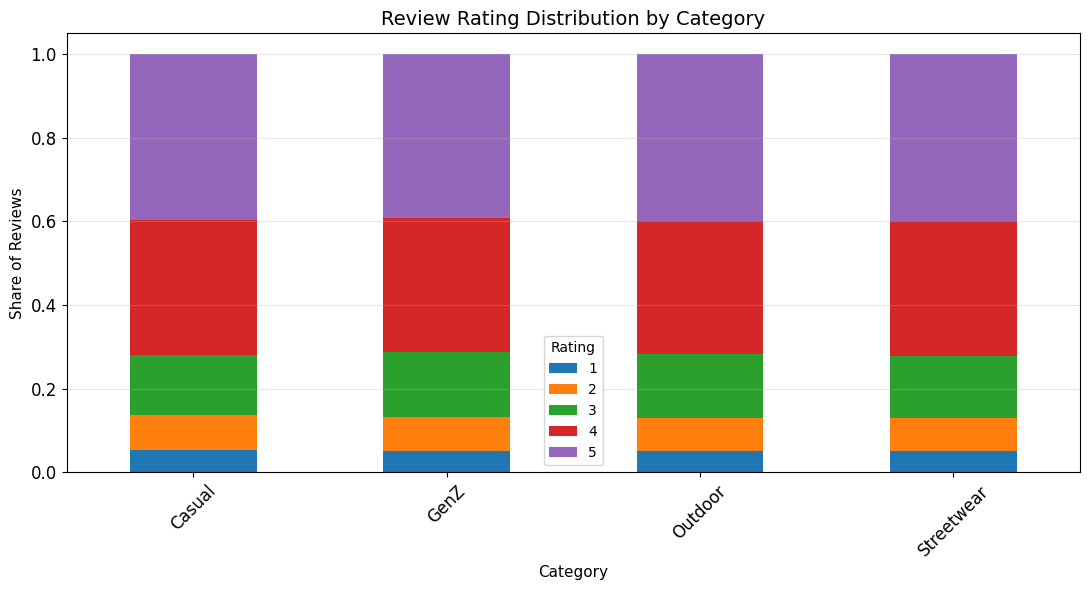

In [21]:
pivot_rating_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Review Rating Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Share of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Rating")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c4_rating_distribution_by_category")
plt.show()

### Cancellation: đơn bị hủy nằm ở đâu?

Saving figure c5_cancel_rate_by_payment_method


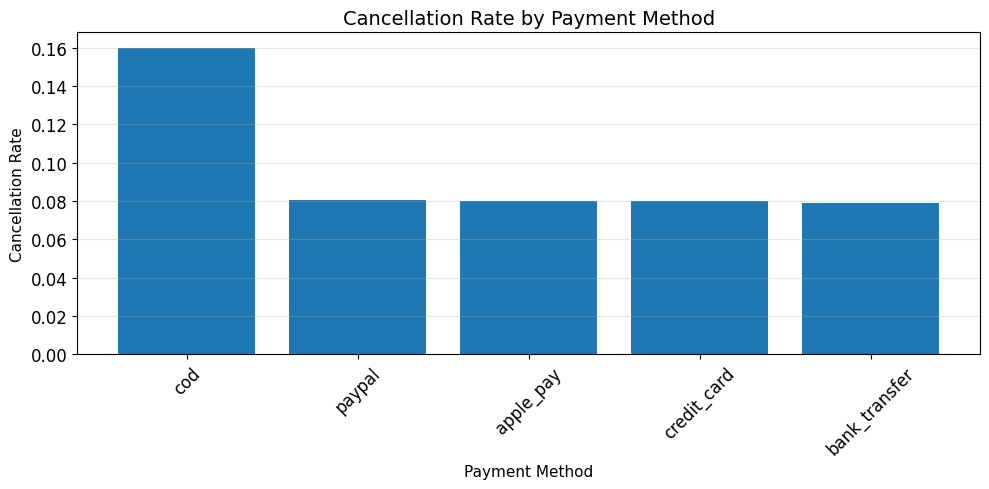

,payment_method,orders,cancel_rate
2,cod,96681,0.159990
4,paypal,97018,0.080573
0,apple_pay,64763,0.080138
3,credit_card,356352,0.079842
1,bank_transfer,32131,0.078896


In [22]:
orders_cancel = orders.copy()
orders_cancel["is_cancelled"] = (orders_cancel["order_status"] == "cancelled").astype(int)

cancel_payment = (
    orders_cancel
    .groupby("payment_method", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean")
    )
    .sort_values("cancel_rate", ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(cancel_payment["payment_method"], cancel_payment["cancel_rate"])

plt.title("Cancellation Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c5_cancel_rate_by_payment_method")
plt.show()

display(cancel_payment)

Saving figure c5_cancel_rate_by_device


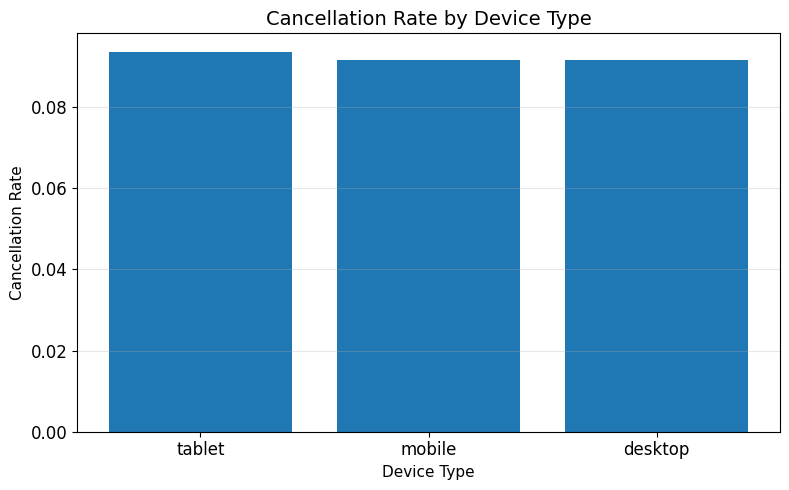

,device_type,orders,cancel_rate
2,tablet,96608,0.093481
1,mobile,291482,0.091642
0,desktop,258855,0.091630


In [23]:
cancel_device = (
    orders_cancel
    .groupby("device_type", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        cancel_rate=("is_cancelled", "mean")
    )
    .sort_values("cancel_rate", ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(cancel_device["device_type"], cancel_device["cancel_rate"])

plt.title("Cancellation Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Cancellation Rate")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("c5_cancel_rate_by_device")
plt.show()

display(cancel_device)